In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp

In [2]:
mode = 'BandRemoval:4'
model_name = "block_phantom"
model_dir = "D:/DeepSSFP/"
path = os.path.join(model_dir, f"{model_name}_{mode.lower().replace(':', '_')}")
ds_path = os.path.join(model_dir, f"{model_name}_dataset.npy")
print(path, ds_path)

D:/DeepSSFP/block_phantom_bandremoval_4 D:/DeepSSFP/block_phantom_dataset.npy


Saved dataset found. Loading from file: D:/DeepSSFP/block_phantom_dataset.npy
(160, 128, 128, 8) (160, 128, 128, 2)
-0.007850567144167804 0.09967612561713209 -0.009491002499543271 0.07863017274655344
Selected indices: [37 35  2]
Figure size: (10, 6)


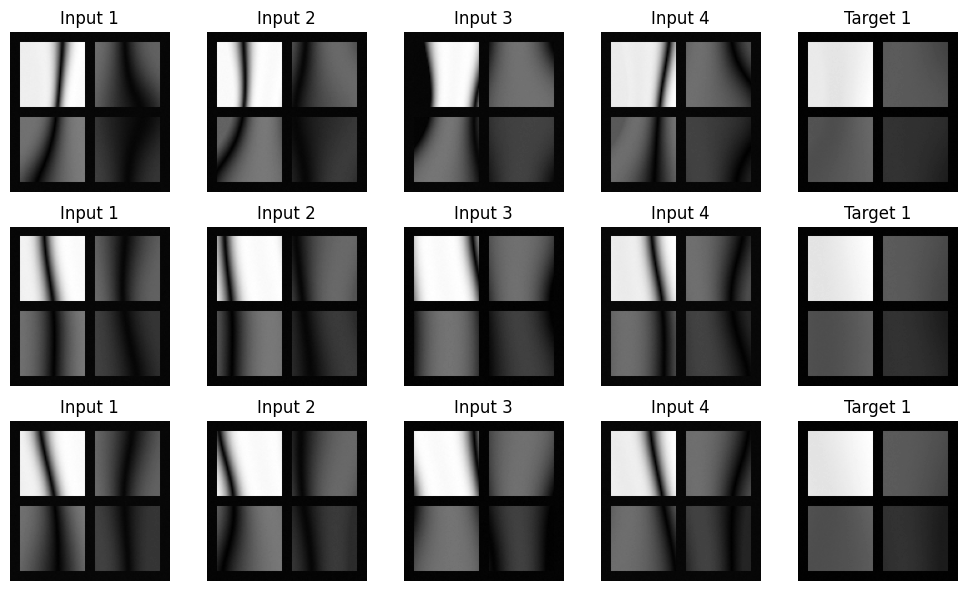

In [3]:
if(os.path.isfile(ds_path)):
    print(f'Saved dataset found. Loading from file: {ds_path}')
    dataset = np.load(ds_path, allow_pickle=True)[0]
else:
    slices = 200
    dataset = mssfp.generate_ssfp_dataset(phantom_type='block', slices=slices, shape=128, ids=[1, 2, 3, 4],
                                          npcs=4, f=500, alpha=np.deg2rad(60), sigma=0.001, data_indices=[(0, 2), (120,180)], 
                                          useRotate=True, useDeform=True)
    np.save(ds_path, [dataset])

data = dataset['M']
ds = deepssfp.dataset.Dataset(mode, input_data=data)
print(ds.x_train.shape, ds.y_train.shape)
print(ds.inputScaler.mean, ds.inputScaler.std, ds.outputScaler.mean, ds.outputScaler.std)

deepssfp.visualize_images(
    input_images=ds.x_test,
    target_images=ds.y_test,
    num_samples=3
)

In [ ]:
# Basic training
model, history, ds, predictions = deepssfp.train(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir,
    custom_dataset=ds,
    epochs=400,
    use_early_stopping=False,
    patience=200,
    continue_training=False
)

2025-03-19 10:59:46,127 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/block_phantom_bandremoval_4
2025-03-19 10:59:46,128 - DeepSSFP - INFO - Training DataSet: (80, 128, 128, 8) | (80, 128, 128, 2)
2025-03-19 10:59:46,129 - DeepSSFP - INFO - Test DataSet: (20, 128, 128, 8) | (20, 128, 128, 2)
2025-03-19 10:59:46,132 - DeepSSFP - INFO - Loading existing model from D:/DeepSSFP/block_phantom_bandremoval_4.keras
2025-03-19 10:59:46,637 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_bandremoval_4_history.npz
2025-03-19 10:59:46,641 - DeepSSFP - INFO - Continuing training from epoch 158


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 128, 128, 8) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 32) 2336        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 128, 128, 32) 128         conv2d_1[0][0]                   
______________________________________________________________________________________________

2025-03-19 10:59:49,758 - tensorflow - WARNING - Callback method `on_train_batch_end` is slow compared to the batch time (batch time: 0.0310s vs `on_train_batch_end` time: 0.1017s). Check your callbacks.


20/20 - 5s - loss: 0.0022 - mean_absolute_error: 0.0339 - val_loss: 0.0014 - val_mean_absolute_error: 0.0268

Epoch 00159: val_loss improved from inf to 0.00141, saving model to D:/DeepSSFP\block_phantom_bandremoval_4.keras
Epoch 160/400
20/20 - 1s - loss: 0.0019 - mean_absolute_error: 0.0324 - val_loss: 6.1024e-04 - val_mean_absolute_error: 0.0184

Epoch 00160: val_loss improved from 0.00141 to 0.00061, saving model to D:/DeepSSFP\block_phantom_bandremoval_4.keras
Epoch 161/400
20/20 - 1s - loss: 0.0018 - mean_absolute_error: 0.0314 - val_loss: 6.7373e-04 - val_mean_absolute_error: 0.0193

Epoch 00161: val_loss did not improve from 0.00061
Epoch 162/400
20/20 - 1s - loss: 0.0020 - mean_absolute_error: 0.0335 - val_loss: 0.0016 - val_mean_absolute_error: 0.0274

Epoch 00162: val_loss did not improve from 0.00061
Epoch 163/400
20/20 - 1s - loss: 0.0018 - mean_absolute_error: 0.0320 - val_loss: 5.8406e-04 - val_mean_absolute_error: 0.0174

Epoch 00163: val_loss improved from 0.00061 to 0

2025-03-19 11:08:02,584 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/block_phantom_bandremoval_4.keras


1/1 [==============================] - 1s 1s/step - loss: 4.0798e-04 - mean_absolute_error: 0.0148


2025-03-19 11:08:03,891 - DeepSSFP - INFO - Training Complete. Loss: 0.0004, MAE: 0.0148
2025-03-19 11:08:03,892 - DeepSSFP - INFO - Time Elapsed: 497.24 seconds


2025-03-19 11:09:57,101 - DeepSSFP - INFO - Loading model from path: D:/DeepSSFP/block_phantom_bandremoval_4
2025-03-19 11:09:57,758 - DeepSSFP - INFO - Model loaded successfully from D:/DeepSSFP/block_phantom_bandremoval_4.keras
2025-03-19 11:09:57,759 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/block_phantom_bandremoval_4_history.npz
2025-03-19 11:09:58,568 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/block_phantom_bandremoval_4_training_history.png


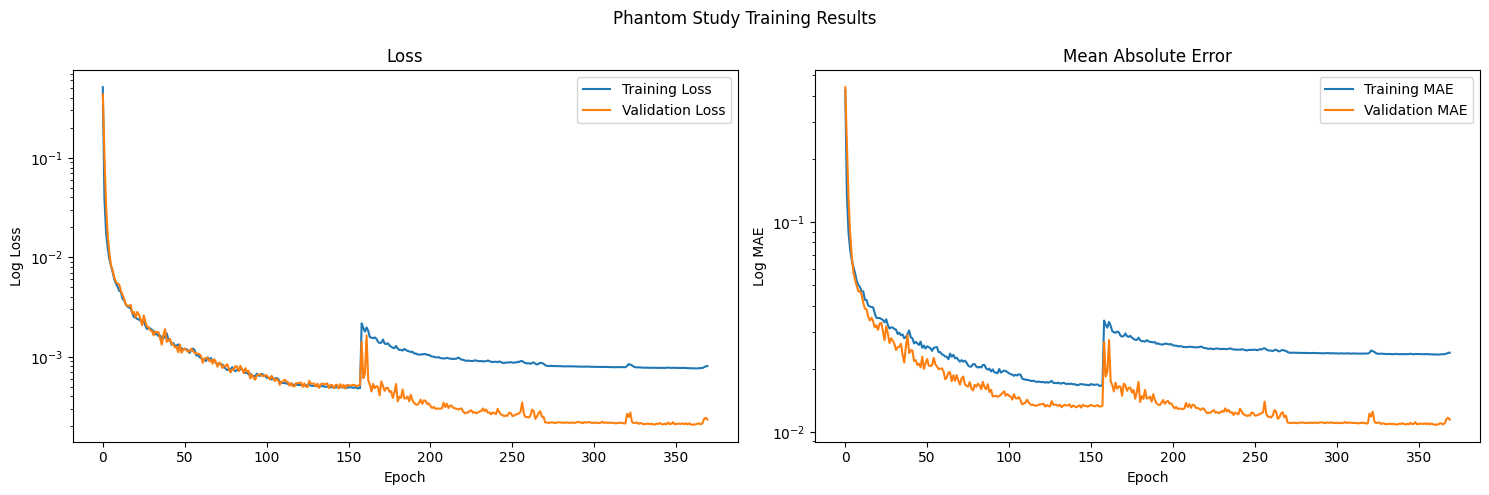

In [ ]:
model, history_dict = deepssfp.load_model(
    mode=mode,
    model_name=model_name,
    model_dir=model_dir
)

deepssfp.plot_training_history(
    history_dict,
    title="Phantom Study Training Results",
    save_path=f"{path}_training_history.png"
)

2025-03-19 10:56:23,030 - DeepSSFP - INFO - Making predictions on data with shape (20, 128, 128, 8)
2025-03-19 10:56:26,794 - DeepSSFP - INFO - Predictions complete. Output shape: (20, 128, 128, 2)
2025-03-19 10:56:32,572 - DeepSSFP - INFO - Prediction visualization saved to prediction_results.png


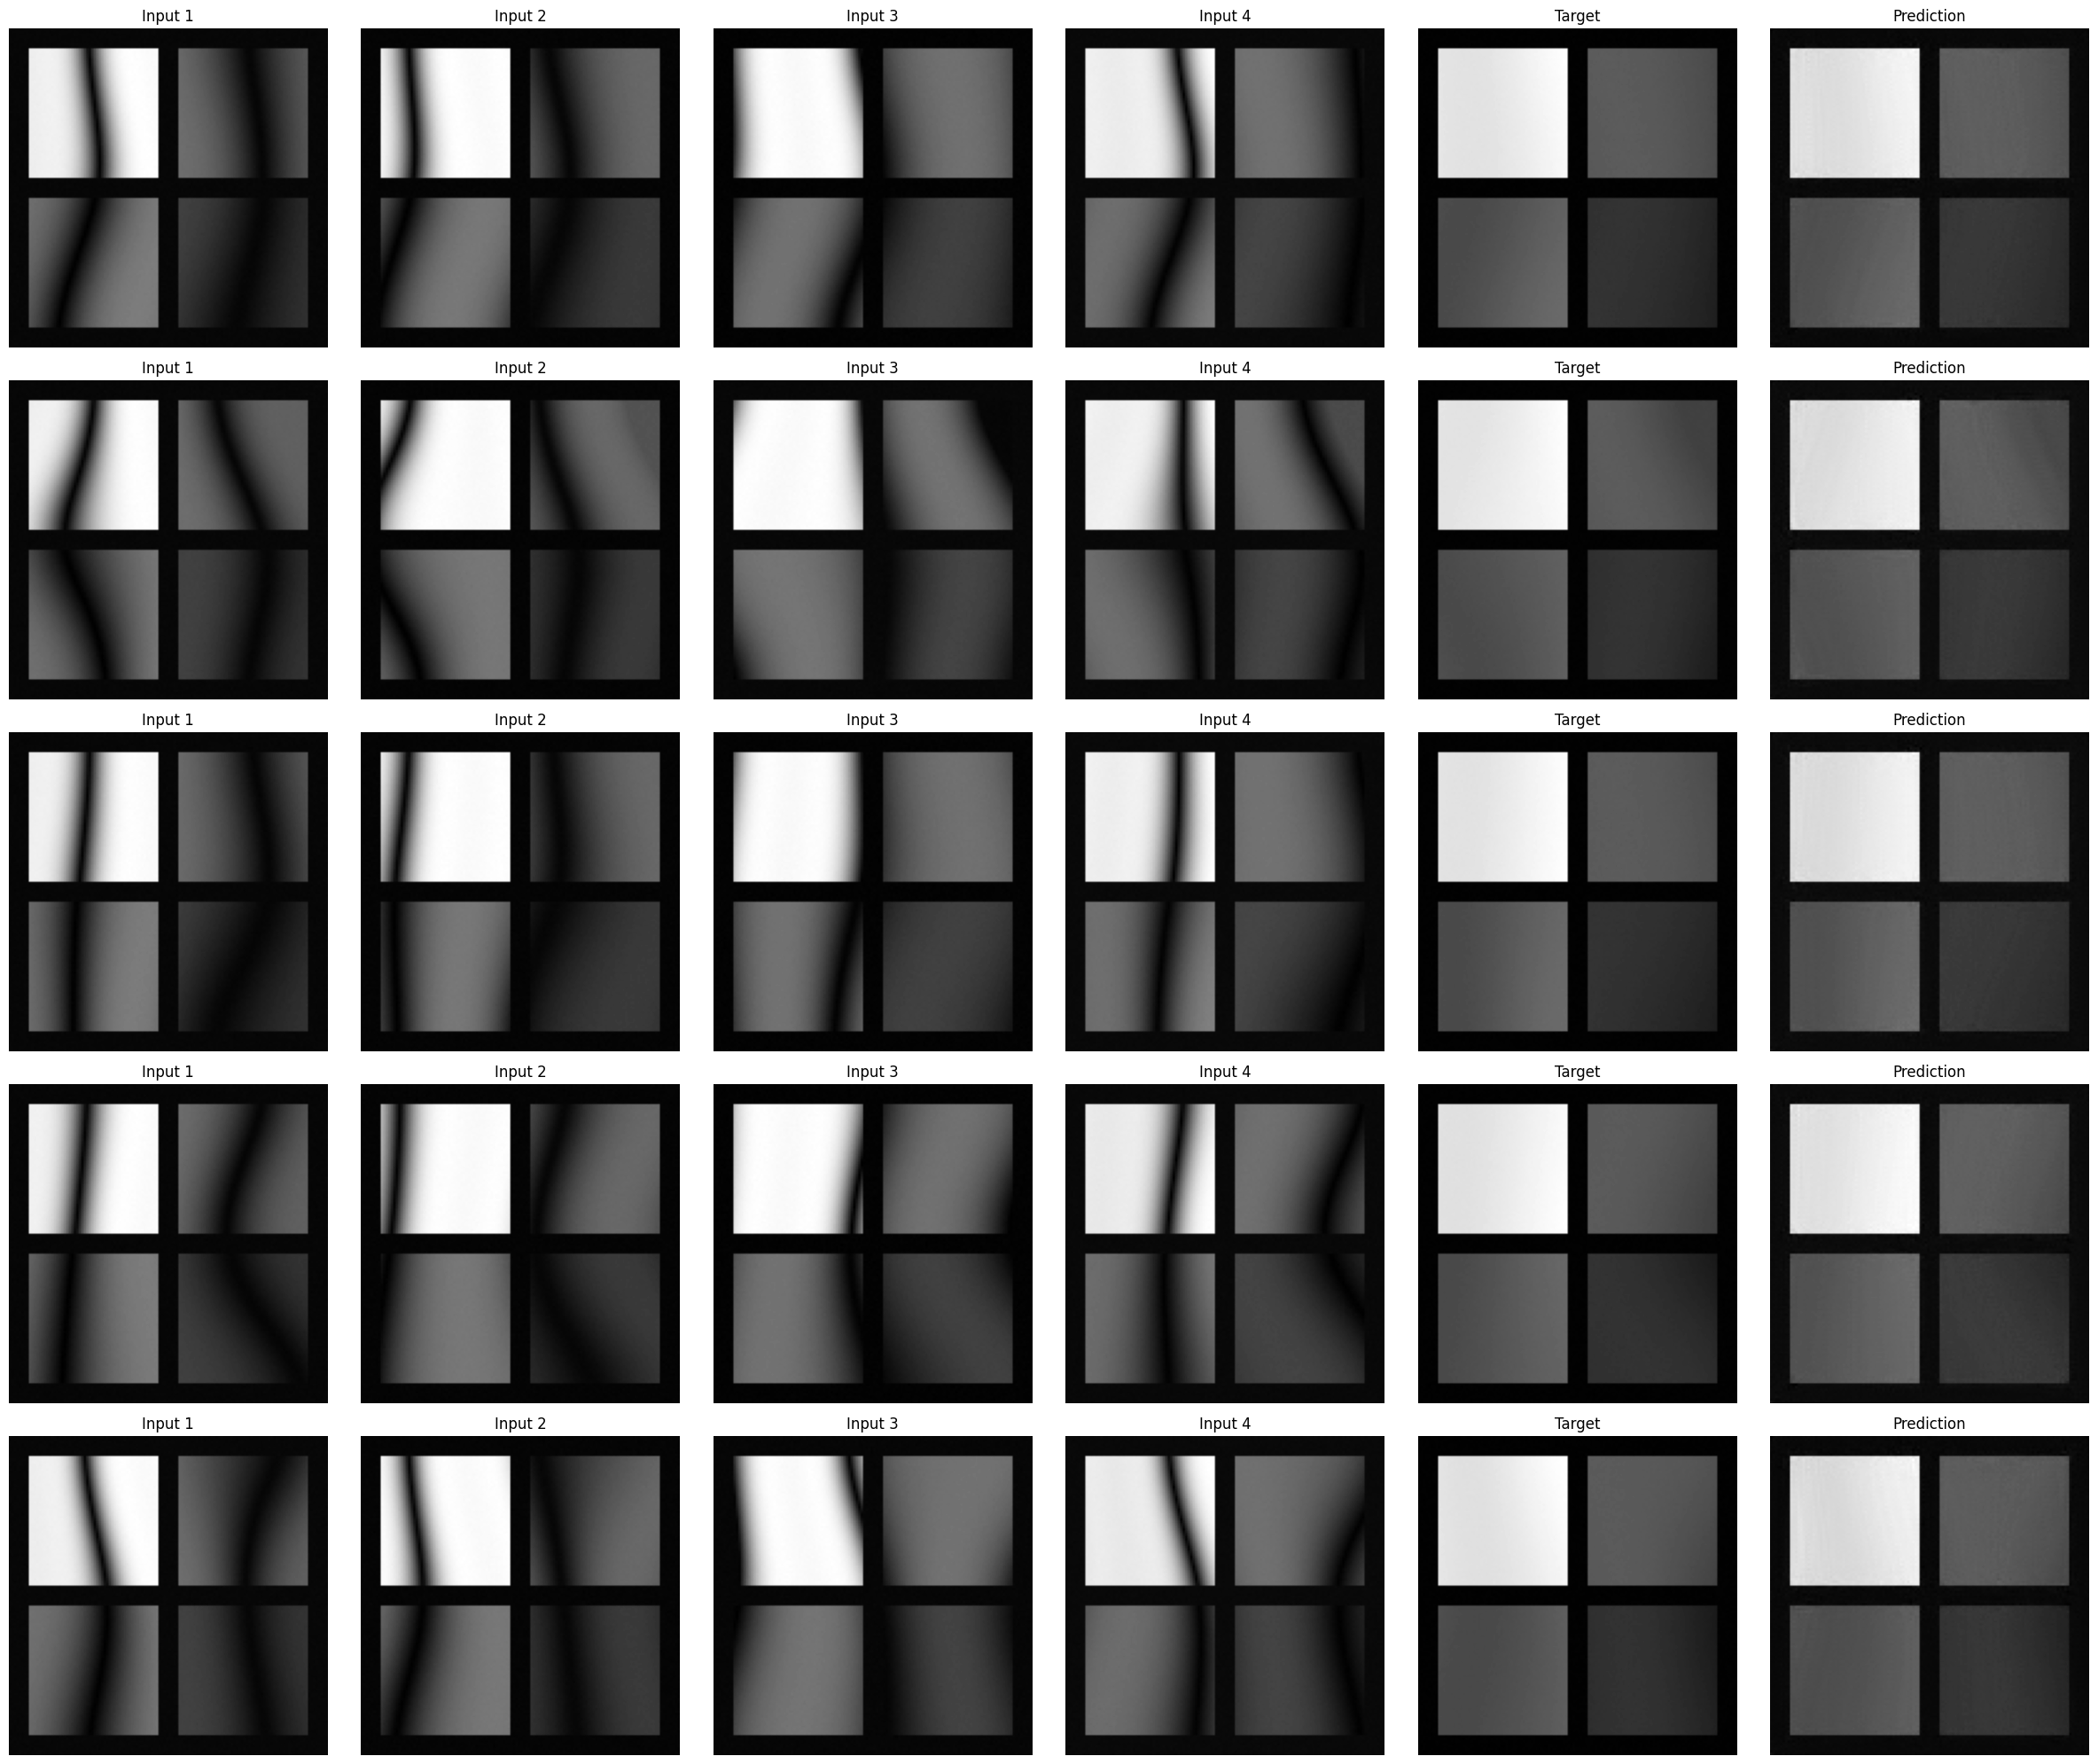

In [ ]:
ds = deepssfp.Dataset(mode, input_data=data)
x_test = ds.inputScaler.inverse_transform(ds.x_test)
y_test = ds.outputScaler.inverse_transform(ds.y_test)
predictions = ds.inputScaler.inverse_transform(deepssfp.predict(model, ds.x_test))

print(predictions.shape, predictions.dtype)
print(x_test.shape, y_test.shape, x_test.dtype, y_test.dtype)
deepssfp.visualize_images([0], x_test, y_test, predictions, save_path=f"{path}_prediction_results.png")

In [ ]:
pred = deepssfp.from_pairs_to_complex(predictions)
target = deepssfp.from_pairs_to_complex(y_test)
print(target.shape, pred.shape)

plt.plot(np.abs(target[0,20,:]))
plt.plot(np.abs(pred[0,20,:]))
plt.show()

metrics = deepssfp.evaluate_band_reduction(target, pred, dataset['seg'], sort_values=False, fig_size=(6, 2), save_path=f"{path}_metrics")
print(metrics)

2025-03-19 10:56:34,213 - DeepSSFP - INFO - MSE: 0.0007 ± 0.0001
2025-03-19 10:56:34,213 - DeepSSFP - INFO - PSNR: 41.5989 ± 0.6076
2025-03-19 10:56:34,214 - DeepSSFP - INFO - SSIM: 0.9831 ± 0.0021
2025-03-19 10:56:34,214 - DeepSSFP - INFO - NRMSE: 0.0089 ± 0.0007
2025-03-19 10:56:34,215 - DeepSSFP - INFO - MAE: 0.0208 ± 0.0011
2025-03-19 10:56:34,215 - DeepSSFP - INFO - VIF: 0.9719 ± 0.0209


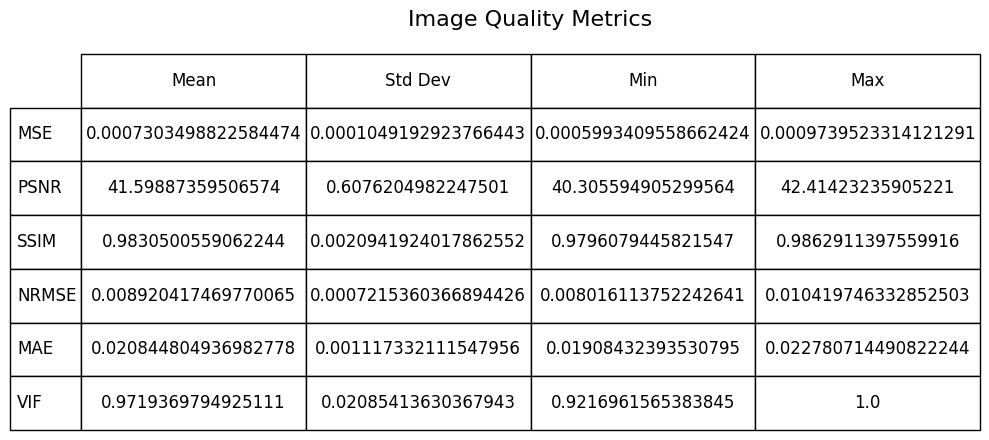

2025-03-19 10:56:34,682 - DeepSSFP - INFO - Metrics saved to metrics_results.xlsx
2025-03-19 10:56:36,234 - DeepSSFP - INFO - Metric distributions plot saved to metric_distributions.png


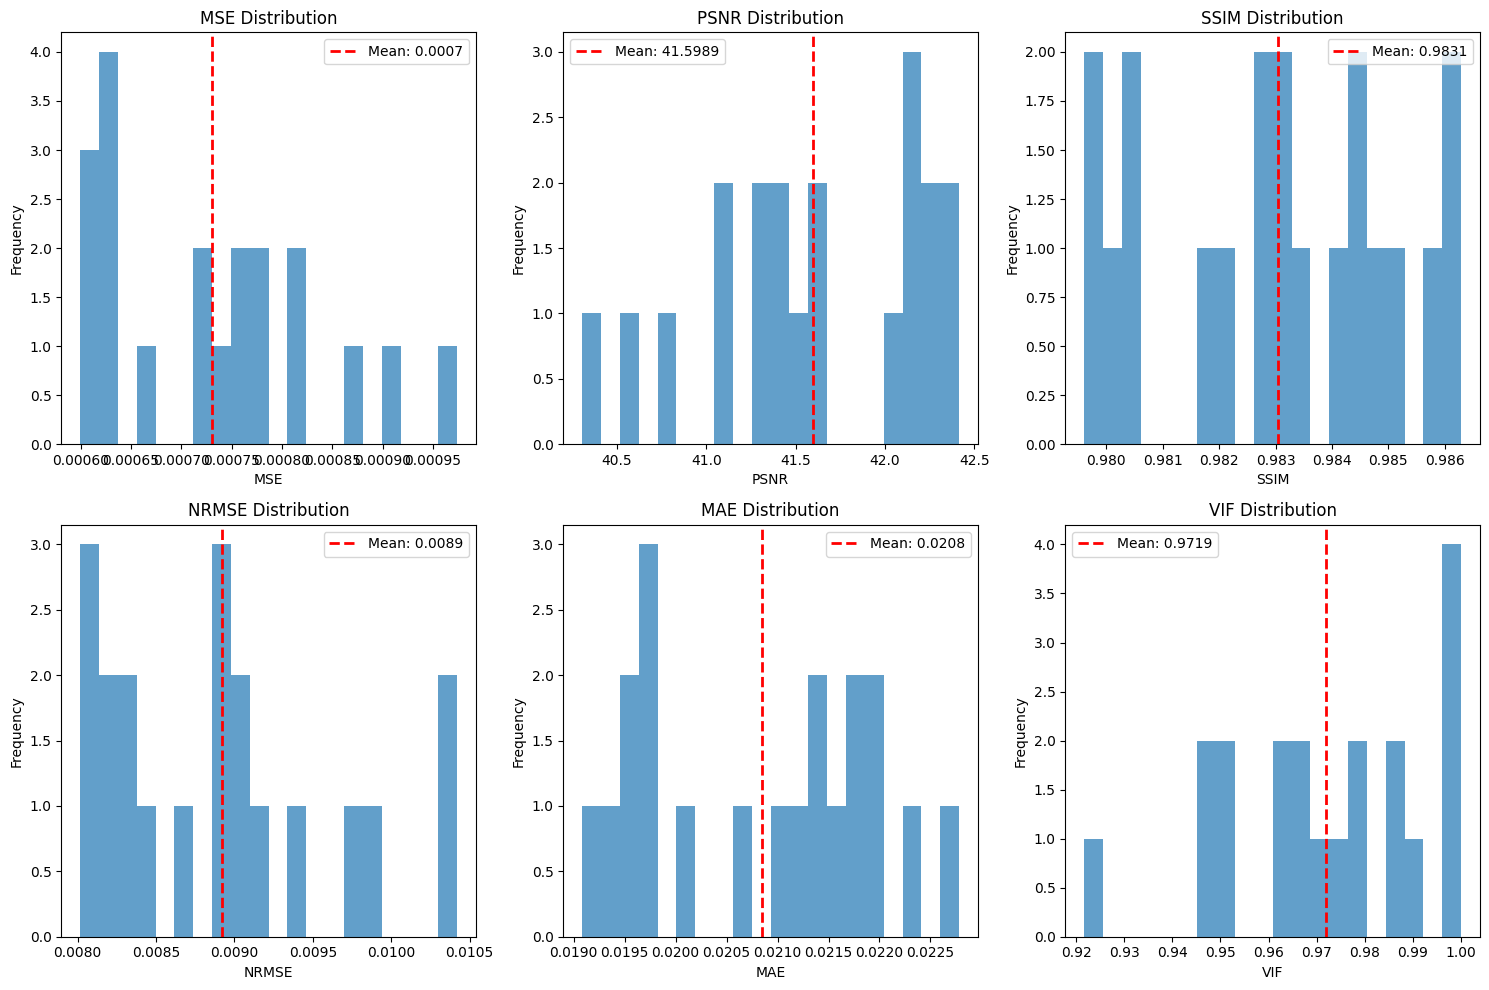

2025-03-19 10:56:36,833 - DeepSSFP - INFO - MRI-Specific Metrics:
2025-03-19 10:56:36,834 - DeepSSFP - INFO - Banding Reduction: 76.8339 ± 1.8848
2025-03-19 10:56:36,835 - DeepSSFP - INFO - Snr Improvement: 0.9995 ± 0.0012
2025-03-19 10:56:36,835 - DeepSSFP - INFO - Edge Preservation: 0.9985 ± 0.0002
2025-03-19 10:56:37,524 - DeepSSFP - INFO - MRI metrics plot saved to mri_specific_metrics.png


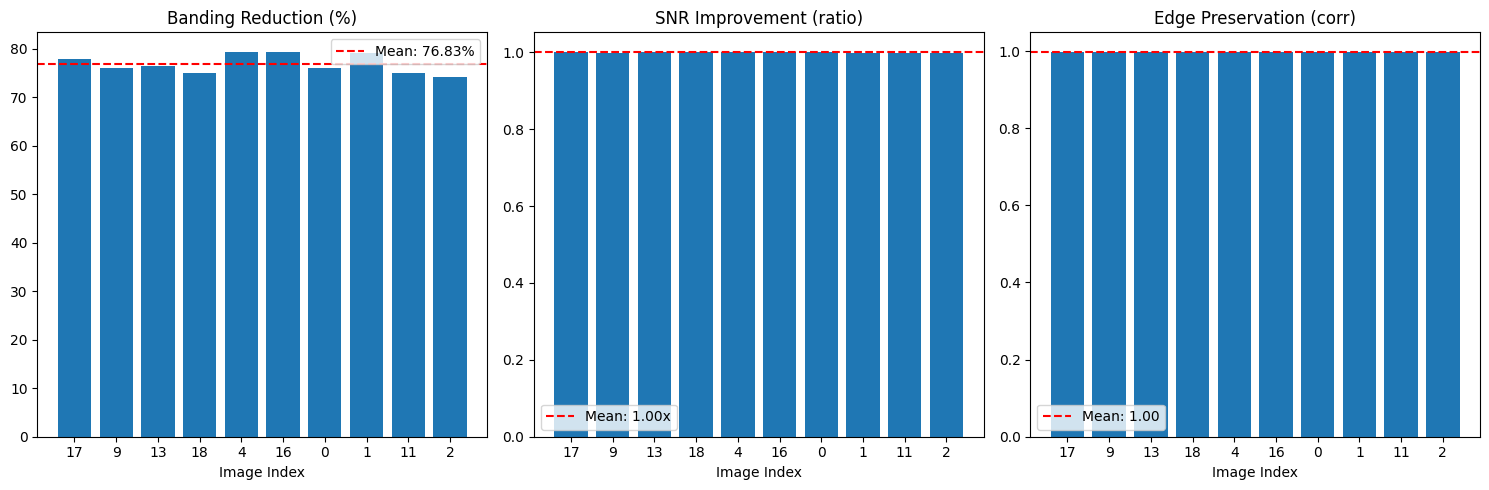

In [8]:
# After generating predictions

# For standard image quality metrics
metrics_results = deepssfp.evaluate_predictions(
    target_images=ds.y_test,
    predicted_images=predictions,
    metrics=['mse', 'psnr', 'ssim', 'nrmse', 'mae', 'vif'],  # Choose metrics you want
    display_results=True,
    save_path="metrics_results.xlsx"  # Save detailed results
)

# Plot distributions of metrics across your test set
deepssfp.plot_metric_distributions(
    metrics_results,
    save_path="metric_distributions.png"
)

# For MRI-specific metrics focused on artifact removal
mri_metrics = deepssfp.evaluate_artifact_removal(
    input_images=ds.x_test,
    target_images=ds.y_test,
    predicted_images=predictions,
    num_samples=10,  # Number of samples to evaluate
    save_path="mri_specific_metrics.png"
)

2025-03-19 10:56:37,796 - DeepSSFP - INFO - Estimating ROIs for image 0 with grid size (2, 2)


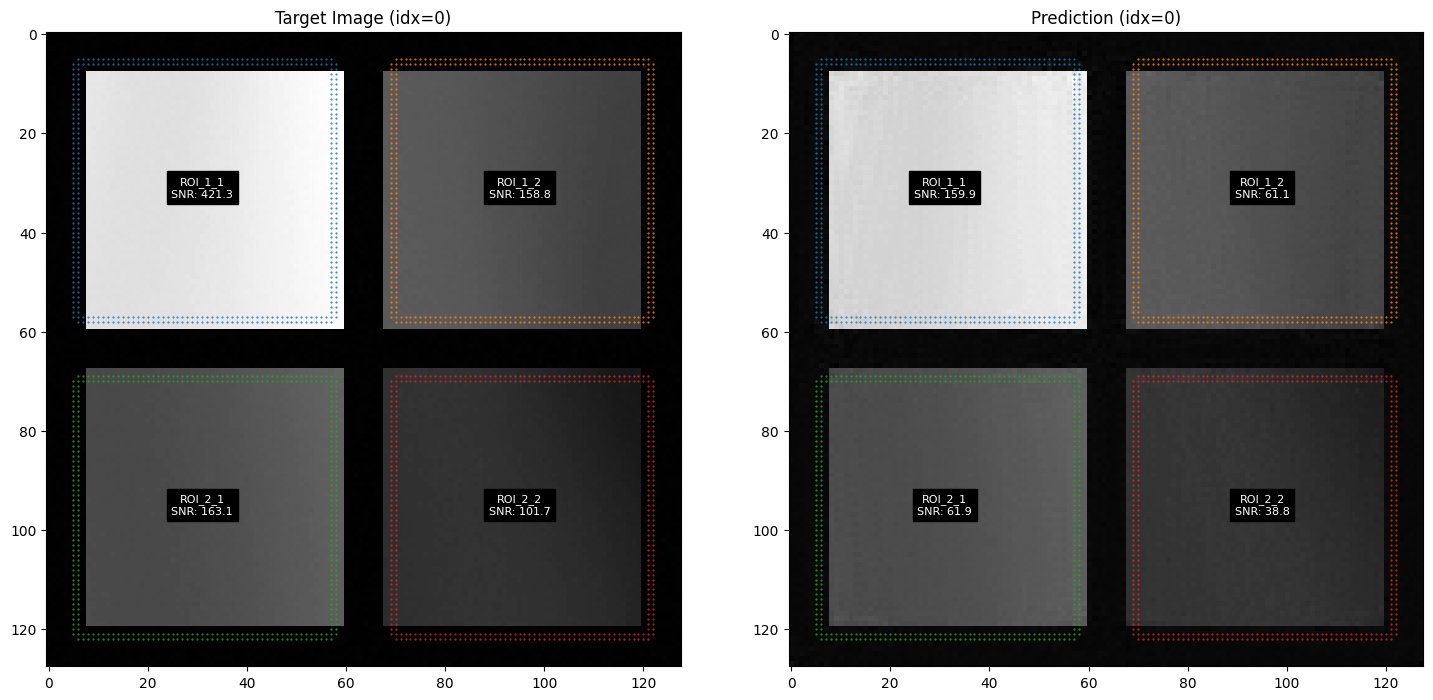

2025-03-19 10:56:38,257 - DeepSSFP - INFO - Estimating ROIs for image 6 with grid size (2, 2)


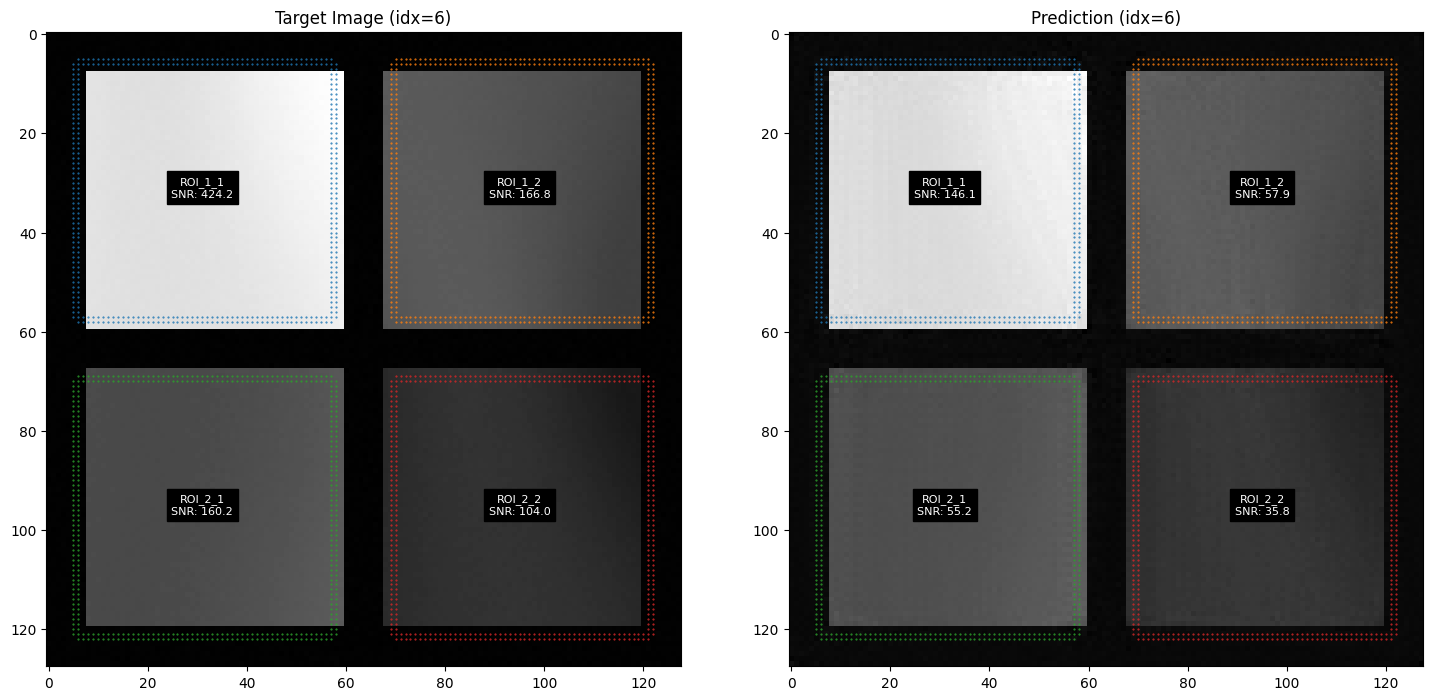

2025-03-19 10:56:38,626 - DeepSSFP - INFO - Estimating ROIs for image 2 with grid size (2, 2)


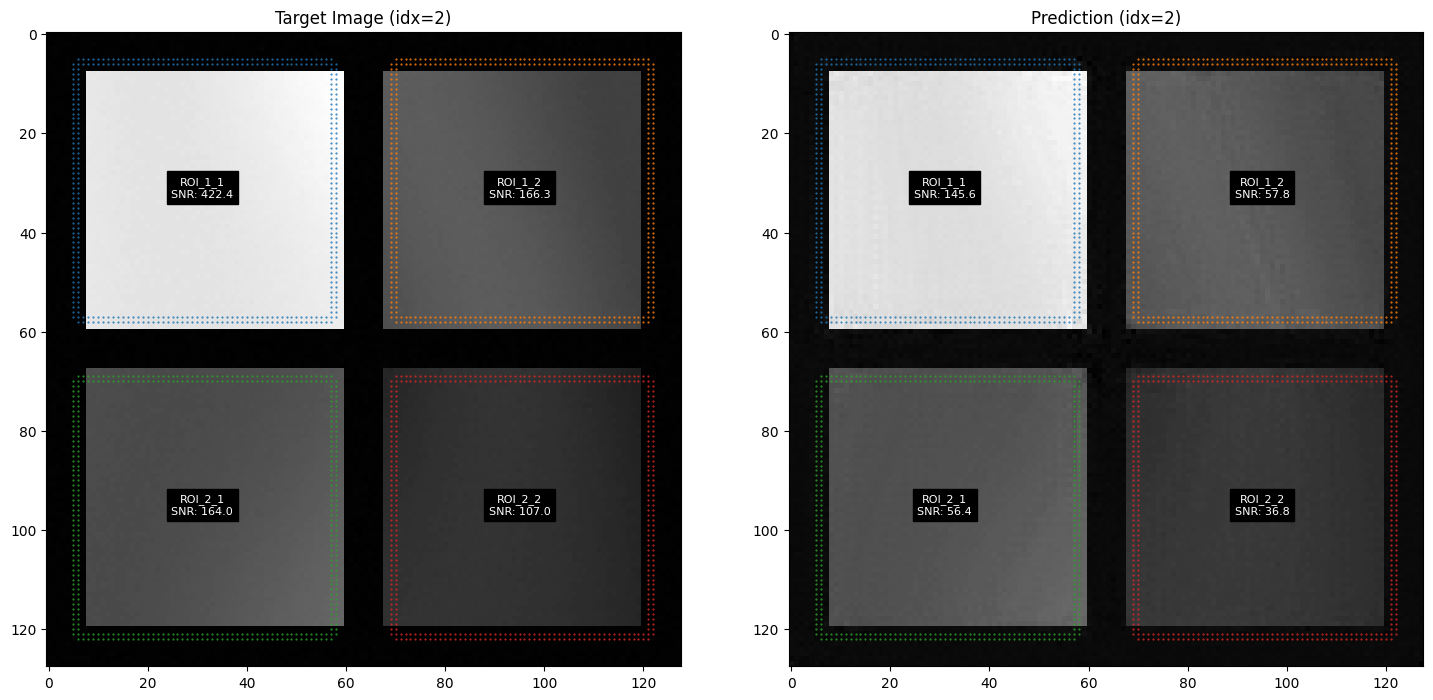

2025-03-19 10:56:38,987 - DeepSSFP - INFO - Estimating ROIs for image 1 with grid size (2, 2)


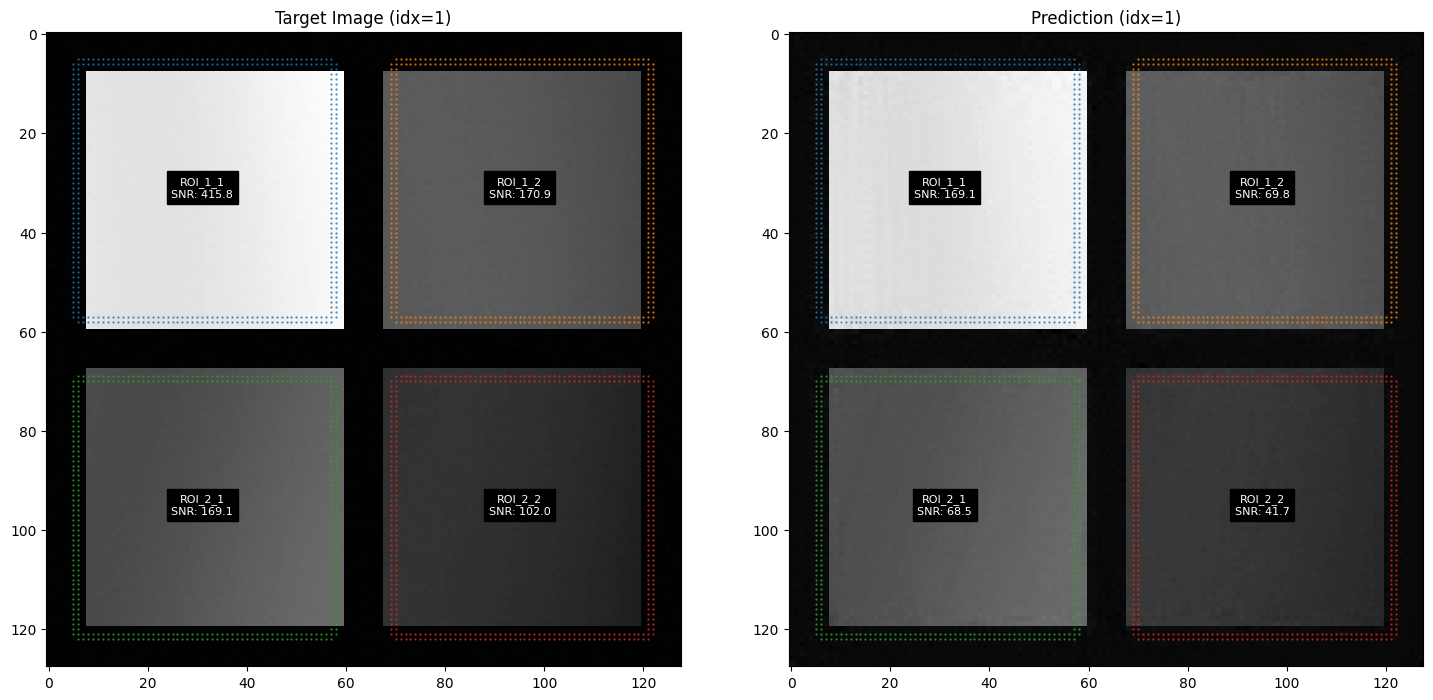

2025-03-19 10:56:39,328 - DeepSSFP - INFO - Estimating ROIs for image 17 with grid size (2, 2)


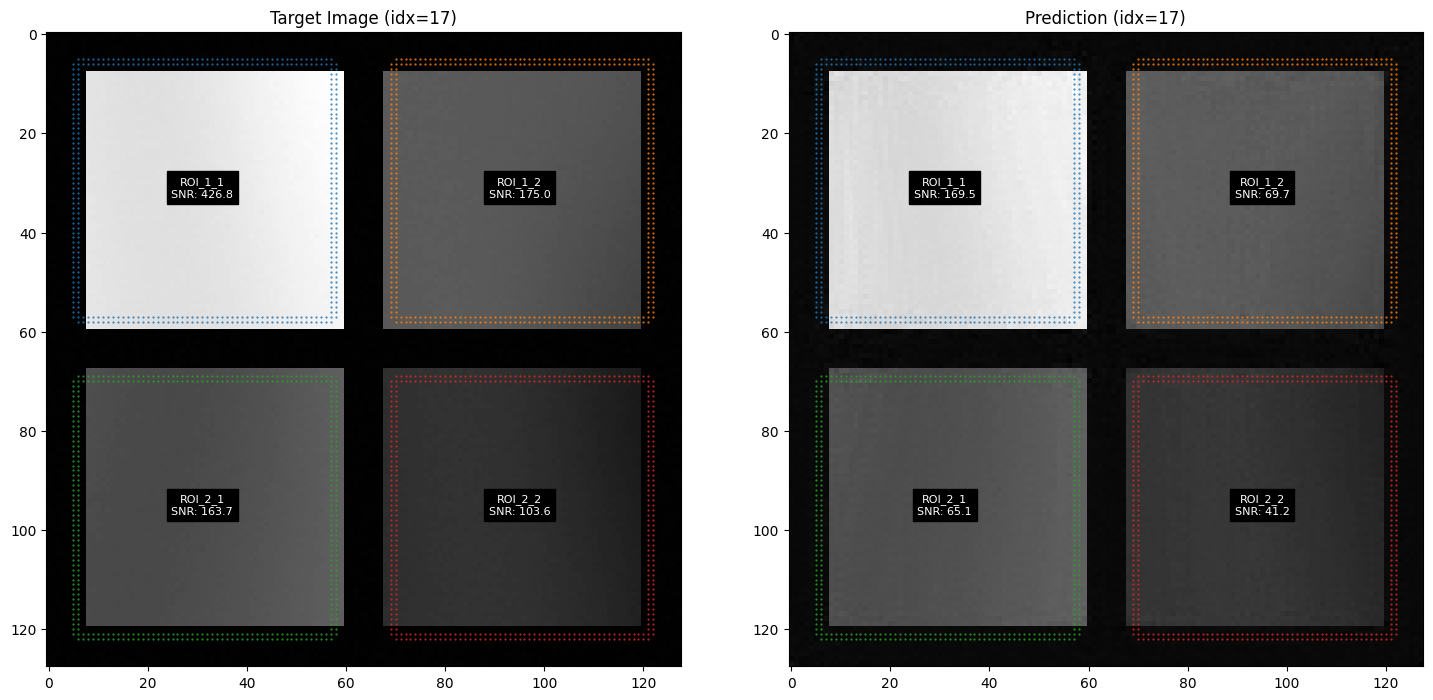

2025-03-19 10:56:39,765 - DeepSSFP - INFO - Tissue contrast analysis saved to tissue_contrast_analysis.xlsx



=== SNR Summary ===
    ROI    Target SNR Prediction SNR Change (%)
ROI_1_1 422.12 ± 3.66 158.04 ± 10.54     -62.6%
ROI_1_2 167.56 ± 5.38   63.26 ± 5.43     -62.2%
ROI_2_1 164.03 ± 2.88   61.44 ± 5.04     -62.5%
ROI_2_2 103.65 ± 1.89   38.85 ± 2.32     -62.5%

=== CNR Summary ===
          ROI Pair    Target CNR Prediction CNR Change (%)
ROI_1_1_vs_ROI_1_2 254.55 ± 5.90   94.78 ± 5.55     -62.8%
ROI_1_1_vs_ROI_2_1 258.09 ± 6.17   96.59 ± 5.77     -62.6%
ROI_1_1_vs_ROI_2_2 318.47 ± 3.38  119.19 ± 8.27     -62.6%
ROI_1_2_vs_ROI_2_1   5.27 ± 3.43    2.13 ± 1.36     -59.6%
ROI_1_2_vs_ROI_2_2  63.91 ± 5.44   24.40 ± 3.22     -61.8%
ROI_2_1_vs_ROI_2_2  60.38 ± 3.91   22.59 ± 2.78     -62.6%

Contrast Preservation: 1.000 ± 0.000


In [9]:
# Analyze tissue contrast with automatic ROI detection
tissue_analysis = deepssfp.analyze_tissue_contrast(
    target_images=ds.y_test,
    predicted_images=predictions,
    grid_size=(2, 2),        # Your phantom has a 2x2 grid of tissues
    margin=0.1,              # 10% margin from edges to avoid boundary effects
    num_samples=5,           # Number of samples to analyze
    save_path="tissue_contrast_analysis.xlsx"
)